Gumede SN 22420947

# eThekwini Municipal Election Analytics & 2026 Local-Election Forecast

**Data source:** Electoral Commission of South Africa (IEC) official results downloads  
- Municipal election results (2011, 2016, 2021): https://results.elections.org.za/home/downloads/me-results  
- National & Provincial Election results (2024): https://results.elections.org.za/home/Downloads/NPE-Results

## Executive objective
This project develops a reproducible election-analytics pipeline for eThekwini Metropolitan Municipality (ETH), KwaZulu-Natal. It follows the complete Machine Learning Life Cycle: problem definition, data acquisition, data understanding, cleaning, integration, EDA, feature engineering, train/validation/test design, baseline modelling, model selection, evaluation, forecasting, interpretation, deployment design, and monitoring.

### Four required analytical outputs
1. Predicted metro-wide leading party and vote share for the next local-government election.
2. Predicted leading party in three selected wards.
3. Predicted party vote totals and vote shares** for the metro.
4. Predicted voter turnout.

### Important methodological position
The 2011/2016/2021 files are Local Government Elections (LGE) and form the primary longitudinal training data. The 2024 file is a National Election (NPE), so it is not treated as a fourth equivalent LGE observation. It is used as a *recent political signal*, especially because uMkhonto weSizwe (MK) did not exist in the historical LGE data. This prevents the invalid assumption that MK had zero historical support merely because it did not yet exist.



## 1. Business / analytical understanding

### Problem statement
The municipality needs an evidence-based forecast of the next local election using historical IEC results. Election forecasting is challenging because ward boundaries, voting districts, party participation and election type can change. The goal is therefore not to claim certainty, but to build a transparent and validated forecasting system and clearly state its assumptions.



### Risks and mitigations
Boundary/identifier changes: align primarily on stable 'VotingDistrict' identifiers and explicitly report match rates; do not assume ward numbers are stable.  
New parties: MK is handled through the observed 2024 eThekwini NPE signal rather than fabricated historical zeros.  
Election-type shift: 2024 NPE is used only as a recent-signal scenario adjustment, not as an equivalent LGE training target.  
Class imbalance: report macro-F1 and per-class metrics alongside accuracy.  
Overfitting: use group-disjoint train/validation/test sets, baselines and a final untouched test set.

In [1]:
# 2. Environment and imports
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')
import warnings, re, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
print("Environment ready.")

Mounted at /content/drive
Environment ready.


## 3. Data acquisition and provenance
All four files were downloaded from the **official IEC results portal**, making the data credible and traceable. The raw files are preserved; transformations are performed in memory. The 2011 CSV uses UTF-16 encoding while later LGE files use UTF-8. The 2024 report is a formatted CSV export rather than a normal rectangular table, so it requires a dedicated parser.

In [2]:
# ============================================================
# DATA ACCESS: GOOGLE DRIVE
# ============================================================
# The datasets used in this project are stored in Google Drive.
# Google Drive is mounted in Colab so that the original CSV
# files can be accessed directly without modifying their contents.


# Folder containing the four original IEC CSV files.
BASE = Path("/content/drive/MyDrive/TP2 FINAL EXAM 2026")

FILES = {
    2011: BASE / "2011 LOCAL GOVERNMENT.csv",
    2016: BASE / "2016 LOCAL GOVERNMENT.csv",
    2021: BASE / "2021 LOCAL GOVERNMENT.csv",
    2024: BASE / "2024 NATIONAL.csv",
}

# Validate that all required source files are available before
# continuing with the analysis.
for year, path in FILES.items():
    assert path.exists(), (
        f"Missing required file for {year}: {path}\n"
        "Check the Google Drive folder and filename."
    )
    print(f"{year} -> {path}")

2011 -> /content/drive/MyDrive/TP2 FINAL EXAM 2026/2011 LOCAL GOVERNMENT.csv
2016 -> /content/drive/MyDrive/TP2 FINAL EXAM 2026/2016 LOCAL GOVERNMENT.csv
2021 -> /content/drive/MyDrive/TP2 FINAL EXAM 2026/2021 LOCAL GOVERNMENT.csv
2024 -> /content/drive/MyDrive/TP2 FINAL EXAM 2026/2024 NATIONAL.csv


In [3]:
# Load the three LGE files with their correct encodings
def load_lge(year):
    encoding = "utf-16" if year == 2011 else "utf-8"
    df = pd.read_csv(FILES[year], encoding=encoding)
    df["ElectionYear"] = year
    return df

lge_raw = {year: load_lge(year) for year in (2011, 2016, 2021)}
for year, df in lge_raw.items():
    print(f"{year}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    display(df.head(2))

2011: 24,843 rows x 12 columns


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated,ElectionYear
0,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,5/26/2011 4:40:02 PM,2011
1,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,5/26/2011 4:40:02 PM,2011


2016: 40,706 rows x 12 columns


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated,ElectionYear
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,ACADEMIC CONGRESS UNION,0,8/11/2016 12:55:57 PM,2016
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,8/11/2016 12:55:57 PM,2016


2021: 76,740 rows x 12 columns


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated,ElectionYear
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ABANTU BATHO CONGRESS,14,11/23/2021 4:26:30 PM,2021
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACADEMIC CONGRESS UNION,0,11/23/2021 4:26:30 PM,2021


In [4]:
# ============================================================
# LOAD AND PARSE 2024 NATIONAL ELECTION DATA
# ============================================================
# The 2024 IEC National Election file has a different structure
# from the Local Government Election files. It contains report
# metadata before the actual party-results table.
#
# It is therefore loaded without assuming a header and parsed
# separately.
#
# IMPORTANT:
# The 2024 election is a National Election (NPE), not a Local
# Government Election (LGE). It will therefore NOT be treated
# as another equivalent historical LGE observation. Instead,
# it provides a recent political signal, particularly for new
# parties such as uMkhonto weSizwe (MK).

npe_raw = pd.read_csv(
    FILES[2024],
    header=None,
    dtype=str
)


def parse_2024_report(raw):
    """
    Extract party-level results from the formatted IEC 2024
    National Election CSV report.

    Returns
    -------
    pandas.DataFrame
        Party-level table containing:
        PartyName, Abbreviation, Votes2024 and Pct2024.
    """

    records = []

    for _, row in raw.iterrows():

        # Remove missing cells and surrounding whitespace.
        vals = [
            str(v).strip()
            for v in row.dropna().tolist()
            if str(v).strip()
        ]

        # Party-result rows end with a percentage.
        if len(vals) >= 4 and vals[-1].endswith("%"):

            try:
                votes = int(vals[-2].replace(",", ""))
                pct = float(vals[-1].replace("%", ""))

                records.append({
                    "PartyName": vals[0],
                    "Abbreviation": vals[-3],
                    "Votes2024": votes,
                    "Pct2024": pct
                })

            except ValueError:
                # Ignore metadata/header rows that resemble
                # result rows but do not contain valid numbers.
                pass

    result = pd.DataFrame(records)

    return (
        result
        .drop_duplicates(subset="PartyName")
        .reset_index(drop=True)
    )


# Parse the raw report.
npe2024 = parse_2024_report(npe_raw)

# Stop execution if parsing was unsuccessful.
assert not npe2024.empty, (
    "The 2024 parser found no party-result rows."
)

print(f"Successfully parsed {len(npe2024):,} parties from the 2024 IEC report.")

display(
    npe2024
    .sort_values("Votes2024", ascending=False)
    .head(10)
)

Successfully parsed 52 parties from the 2024 IEC report.


,PartyName,Abbreviation,Votes2024,Pct2024
46,UMKHONTO WESIZWE,M.K.,602632,48.14
26,DEMOCRATIC ALLIANCE,DA,300652,24.02
13,AFRICAN NATIONAL CONGRESS,ANC,190525,15.22
33,INKATHA FREEDOM PARTY,IFP,68800,5.50
28,ECONOMIC FREEDOM FIGHTERS,EFF,35162,2.81
4,ACTIONSA,ACTIONSA,6023,0.48
7,AFRICAN CHRISTIAN DEMOCRATIC PARTY,ACDP,5947,0.48
39,PATRIOTIC ALLIANCE,PA,4351,0.35
20,ALLIED MOVEMENT FOR CHANGE,AM4C,3656,0.29
27,DEMOCRATIC LIBERAL CONGRESS,DLC,3536,0.28


## 4. Data understanding and quality audit
Before cleaning or modelling, the structure, types, missingness, duplicates and election-specific coverage are audited. This is necessary because duplicated values such as `RegisteredVoters` and `SpoiltVotes` repeat once per party row and must **not** be summed across parties.

In [5]:
audit_rows = []
for year, df in lge_raw.items():
    audit_rows.append({
        "year": year, "rows": len(df), "columns": df.shape[1],
        "wards": df["Ward"].nunique(), "voting_districts": df["VotingDistrict"].nunique(),
        "parties": df["PartyName"].nunique(),
        "missing_cells": int(df.isna().sum().sum()),
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "ballot_types": ", ".join(sorted(df["BallotType"].dropna().astype(str).unique()))
    })
audit = pd.DataFrame(audit_rows)
display(audit)

,year,rows,columns,wards,voting_districts,parties,missing_cells,exact_duplicate_rows,ballot_types
0,2011,24843,12,103,801,19,0,0,"PR, Ward"
1,2016,40706,12,110,866,28,0,0,"PR, Ward"
2,2021,76740,12,111,875,54,0,0,"PR, Ward"


In [6]:
# Data type/range checks and municipality scope
for year, df in lge_raw.items():
    print("\n", year)
    print("Municipalities:", df["Municipality"].dropna().unique())
    print("Negative votes:", (pd.to_numeric(df["TotalValidVotes"], errors="coerce") < 0).sum())
    print("Negative registered voters:", (pd.to_numeric(df["RegisteredVoters"], errors="coerce") < 0).sum())
    print("Ballot types:", df["BallotType"].value_counts().to_dict())


 2011
Municipalities: ['ETH - eThekwini [Durban Metro]']
Negative votes: 0
Negative registered voters: 0
Ballot types: {'PR': 13617, 'Ward': 11226}

 2016
Municipalities: ['ETH - eThekwini']
Negative votes: 0
Negative registered voters: 0
Ballot types: {'PR': 23382, 'Ward': 17324}

 2021
Municipalities: ['ETH - eThekwini']
Negative votes: 0
Negative registered voters: 0
Ballot types: {'PR': 43750, 'Ward': 32990}


### Cleaning rules and justification
1. Standardise text by stripping surrounding whitespace.
2. Coerce identifiers/counts to numeric where appropriate.
3. Remove exact duplicate rows only.
4. Reject impossible negative vote/count values.
5. Use PR ballots for comparable party-vote modelling. Ward ballots can include candidate-specific effects and are therefore not mixed into party-share modelling.
6. At voting-district level, `RegisteredVoters` and `SpoiltVotes` are taken once per district/ballot rather than summed across party rows.
7. Vote share is derived as party votes divided by total valid PR votes in the same geographic unit.

In [7]:
def clean_lge(df):
    d = df.copy()
    text_cols = ["Province","Municipality","Ward","VotingStationName","BallotType","PartyName"]
    for c in text_cols:
        d[c] = d[c].astype(str).str.strip()
    for c in ["VotingDistrict","RegisteredVoters","SpoiltVotes","TotalValidVotes"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d.drop_duplicates()
    d = d.dropna(subset=["VotingDistrict","Ward","PartyName","TotalValidVotes","RegisteredVoters"])
    d = d[(d["TotalValidVotes"] >= 0) & (d["RegisteredVoters"] >= 0) & (d["SpoiltVotes"] >= 0)]
    d["VotingDistrict"] = d["VotingDistrict"].astype(int)
    return d

lge = {year: clean_lge(df) for year, df in lge_raw.items()}
print({year: df.shape for year, df in lge.items()})

{2011: (24843, 12), 2016: (40706, 12), 2021: (76740, 12)}


## 5. Geographic alignment
Ward identifiers are not assumed to be stable across elections. The safer anchor available in these files is the voting-district (VD) identifier. We quantify VD continuity between adjacent elections. Models that use lagged history are trained only where a VD can be matched to its previous election; unmatched/new VDs are retained for descriptive analysis but cannot legitimately receive a lag feature.

In [8]:
vd_sets = {y: set(d["VotingDistrict"].unique()) for y,d in lge.items()}
alignment = []
for a,b in [(2011,2016),(2016,2021)]:
    common = vd_sets[a] & vd_sets[b]
    alignment.append({
        "from": a, "to": b, "VDs_from": len(vd_sets[a]), "VDs_to": len(vd_sets[b]),
        "matched_VDs": len(common), "share_of_later_matched": len(common)/len(vd_sets[b])
    })
alignment = pd.DataFrame(alignment)
display(alignment.style.format({"share_of_later_matched":"{:.1%}"}))

,from,to,VDs_from,VDs_to,matched_VDs,share_of_later_matched
0,2011,2016,801,866,799,92.3%
1,2016,2021,866,875,863,98.6%


In [9]:
# Build one PR snapshot per voting district per election.
def vd_snapshot(df, year):
    pr = df[df["BallotType"].str.upper().eq("PR")].copy()
    party = (pr.groupby(["VotingDistrict","Ward","RegisteredVoters","PartyName"], as_index=False)
               ["TotalValidVotes"].sum())
    rows = []
    for vd, g in party.groupby("VotingDistrict"):
        g = g.sort_values("TotalValidVotes", ascending=False).reset_index(drop=True)
        total_valid = g["TotalValidVotes"].sum()
        # SpoiltVotes repeats by party, so take one value for this VD/PR ballot.
        spoilt = pr.loc[pr["VotingDistrict"].eq(vd), "SpoiltVotes"].iloc[0]
        registered = g["RegisteredVoters"].iloc[0]
        turnout = (total_valid + spoilt) / registered if registered > 0 else np.nan
        rows.append({
            "VotingDistrict": vd, "Year": year, "Ward": g["Ward"].iloc[0],
            "RegisteredVoters": registered, "ValidVotes": total_valid, "SpoiltVotes": spoilt,
            "Turnout": turnout, "Winner": g["PartyName"].iloc[0],
            "TopShare": g["TotalValidVotes"].iloc[0]/total_valid if total_valid else np.nan,
            "RunnerShare": g["TotalValidVotes"].iloc[1]/total_valid if len(g)>1 and total_valid else 0,
            "Margin": (g["TotalValidVotes"].iloc[0]-g["TotalValidVotes"].iloc[1])/total_valid
                      if len(g)>1 and total_valid else np.nan
        })
    return pd.DataFrame(rows)

snapshots = {y: vd_snapshot(lge[y], y) for y in (2011,2016,2021)}
display(pd.concat([s.assign(Election=y) for y,s in snapshots.items()])
        .groupby("Election").agg(VDs=("VotingDistrict","nunique"),
                                 MeanTurnout=("Turnout","mean"),
                                 MedianRegistered=("RegisteredVoters","median")))

,VDs,MeanTurnout,MedianRegistered
Election,,,
2011,801,0.606750,1981.0
2016,866,0.607207,2097.5
2021,875,0.437989,2054.0


# 6. Exploratory Data Analysis (EDA)
The EDA deliberately uses different visual forms because each answers a different analytical question. The eight figures below examine trend, composition, distribution, relationship, geographic dominance, competitiveness and change rather than repeating the same bar chart.

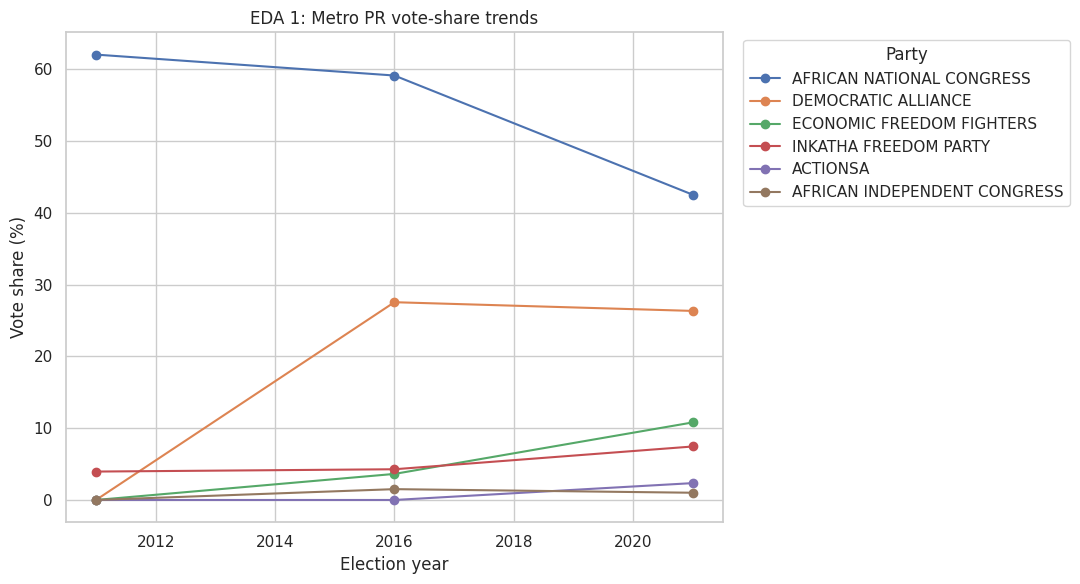

In [10]:
# EDA 1 — LINE: metro party-share trends across LGEs
def metro_party_shares(df):
    pr=df[df.BallotType.str.upper().eq("PR")]
    a=pr.groupby("PartyName").TotalValidVotes.sum()
    return (a/a.sum()).rename("Share")

share_long = pd.concat([metro_party_shares(lge[y]).rename(y) for y in (2011,2016,2021)],axis=1).fillna(0)
top_parties = share_long[2021].nlargest(6).index
plotdf = share_long.loc[top_parties].T*100
ax=plotdf.plot(marker="o", figsize=(11,6))
ax.set(title="EDA 1: Metro PR vote-share trends", xlabel="Election year", ylabel="Vote share (%)")
plt.legend(title="Party", bbox_to_anchor=(1.02,1), loc="upper left"); plt.tight_layout(); plt.show()

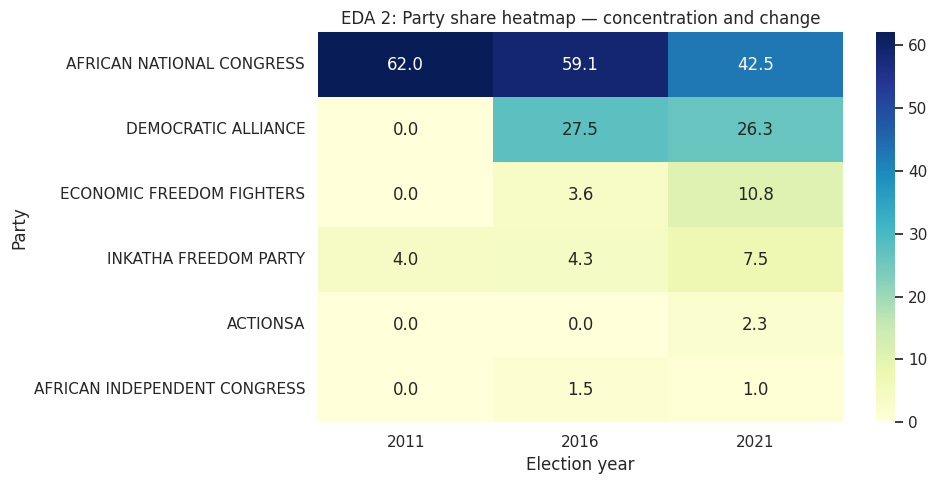

In [11]:
# EDA 2 — HEATMAP: party shares by election
plt.figure(figsize=(10,5))
sns.heatmap((share_long.loc[top_parties]*100), annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("EDA 2: Party share heatmap — concentration and change")
plt.xlabel("Election year"); plt.ylabel("Party"); plt.tight_layout(); plt.show()

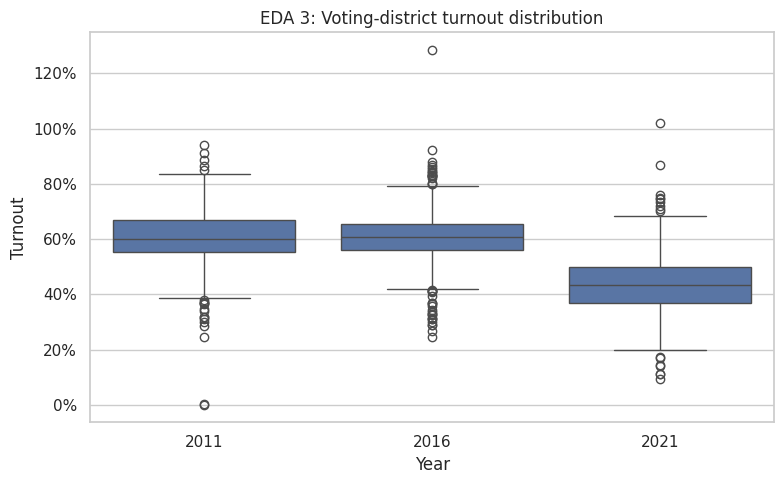

In [12]:
# EDA 3 — BOXPLOT: turnout distribution by election
turnout_all=pd.concat([snapshots[y][["Year","Turnout"]] for y in snapshots],ignore_index=True)
plt.figure(figsize=(8,5))
sns.boxplot(data=turnout_all, x="Year", y="Turnout")
plt.gca().yaxis.set_major_formatter(lambda x,pos:f"{x:.0%}")
plt.title("EDA 3: Voting-district turnout distribution")
plt.ylabel("Turnout"); plt.tight_layout(); plt.show()

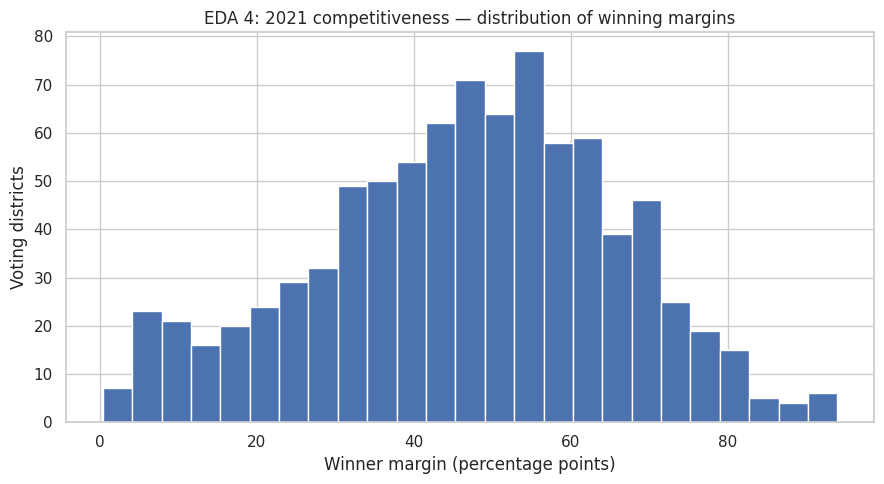

In [13]:
# EDA 4 — HISTOGRAM: competitiveness (winner margin) in 2021
plt.figure(figsize=(9,5))
vals=(snapshots[2021]["Margin"].dropna()*100).to_numpy()
plt.hist(vals, bins=25, edgecolor="white")
plt.title("EDA 4: 2021 competitiveness — distribution of winning margins")
plt.xlabel("Winner margin (percentage points)"); plt.ylabel("Voting districts"); plt.tight_layout(); plt.show()

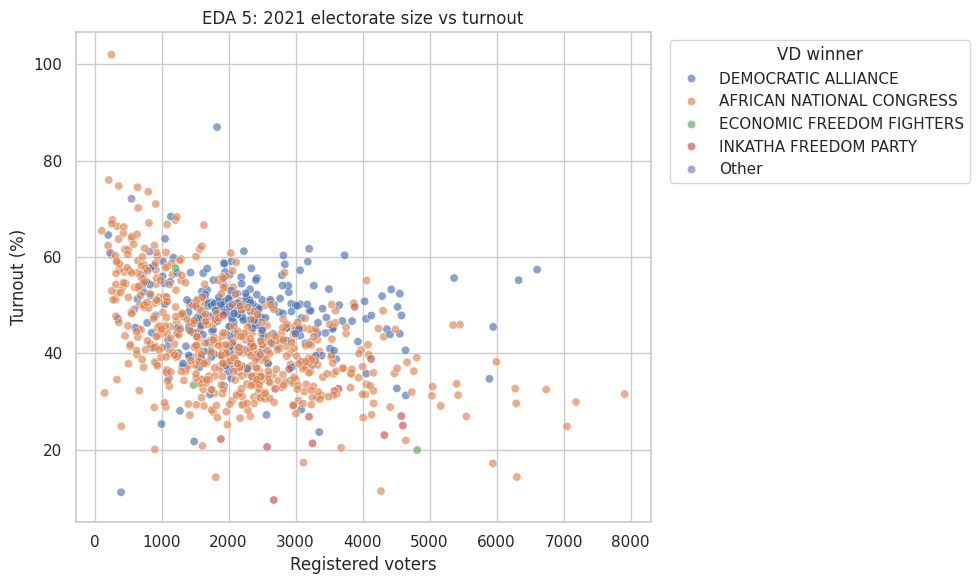

In [14]:
# EDA 5 — SCATTER: electorate size vs turnout, coloured by winner
p=snapshots[2021].copy()
major=p["Winner"].where(p["Winner"].isin(p["Winner"].value_counts().head(4).index),"Other")
plt.figure(figsize=(10,6))
sns.scatterplot(x=p["RegisteredVoters"], y=p["Turnout"]*100, hue=major, alpha=.65)
plt.title("EDA 5: 2021 electorate size vs turnout")
plt.xlabel("Registered voters"); plt.ylabel("Turnout (%)")
plt.legend(title="VD winner", bbox_to_anchor=(1.02,1), loc="upper left"); plt.tight_layout(); plt.show()

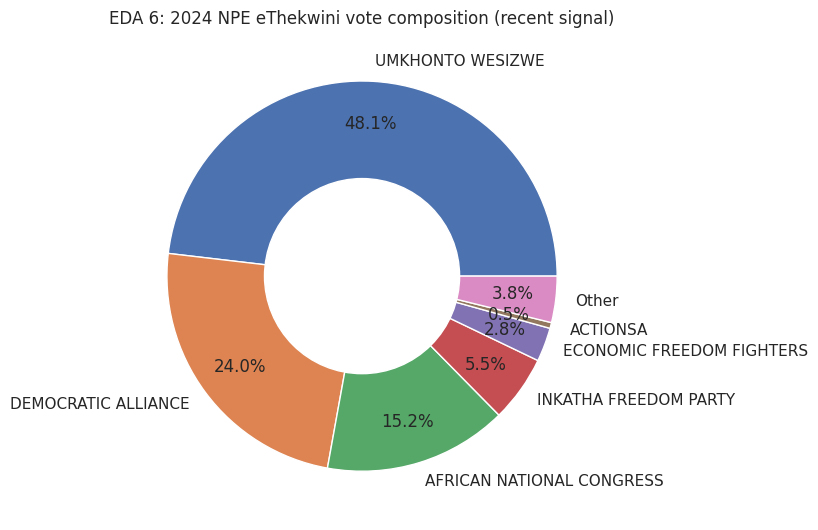

In [15]:
# EDA 6 — DONUT: 2024 eThekwini national-ballot composition
n24=npe2024.sort_values("Votes2024",ascending=False).copy()
top=n24.head(6)
other=n24.iloc[6:]["Votes2024"].sum()
pie=pd.concat([top[["PartyName","Votes2024"]],
               pd.DataFrame({"PartyName":["Other"],"Votes2024":[other]})],ignore_index=True)
plt.figure(figsize=(8,8))
plt.pie(pie.Votes2024, labels=pie.PartyName, autopct="%1.1f%%", pctdistance=.78)
plt.gca().add_artist(plt.Circle((0,0),0.50,fc="white"))
plt.title("EDA 6: 2024 NPE eThekwini vote composition (recent signal)")
plt.tight_layout(); plt.show()

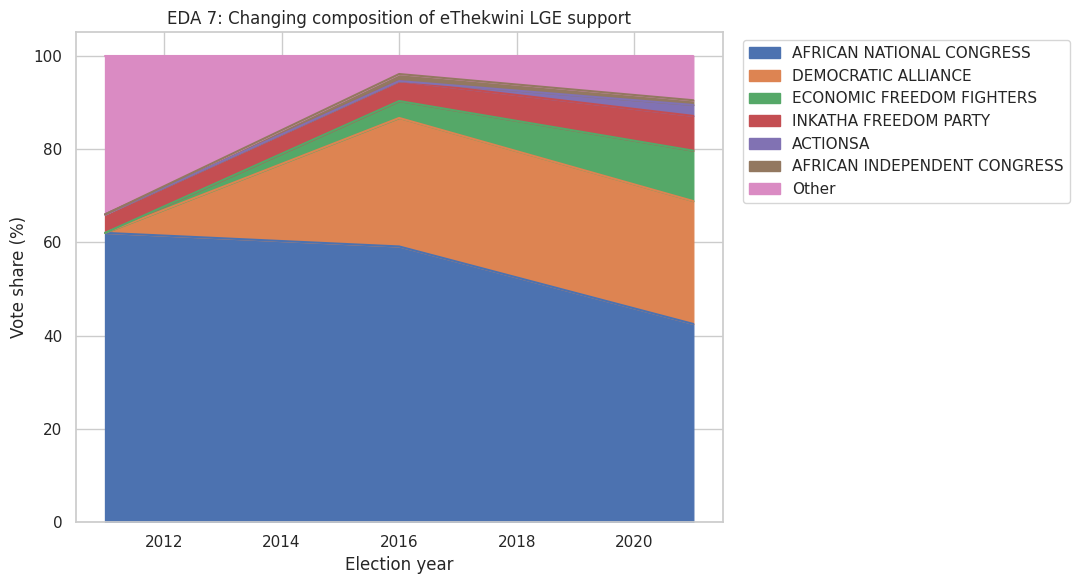

In [16]:
# EDA 7 — STACKED AREA: evolution of the main LGE party shares
area=plotdf.copy()
area["Other"]=100-area.sum(axis=1)
area.plot.area(figsize=(11,6))
plt.title("EDA 7: Changing composition of eThekwini LGE support")
plt.xlabel("Election year"); plt.ylabel("Vote share (%)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left"); plt.tight_layout(); plt.show()

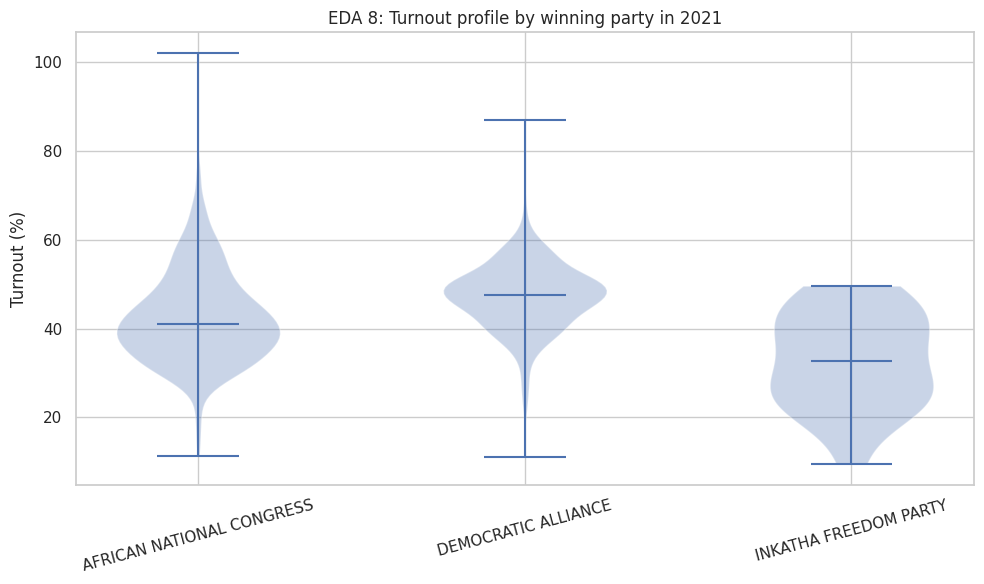

In [17]:
# EDA 8 — VIOLIN: turnout distribution by 2021 winning party (major winners)
major_winners=snapshots[2021]["Winner"].value_counts().head(3).index
v=snapshots[2021][snapshots[2021]["Winner"].isin(major_winners)].copy()
groups=[(v.loc[v.Winner.eq(p),"Turnout"]*100).dropna().to_numpy() for p in major_winners]
plt.figure(figsize=(10,6))
plt.violinplot(groups, showmedians=True)
plt.xticks(range(1,len(major_winners)+1),major_winners,rotation=15)
plt.title("EDA 8: Turnout profile by winning party in 2021")
plt.xlabel(""); plt.ylabel("Turnout (%)"); plt.tight_layout(); plt.show()

### EDA interpretation
The plots should be read together. The line/heatmap/area views show longitudinal party movement; the box/violin plots show that turnout varies materially across places and election years; the scatter plot tests whether electorate size is associated with participation; the margin histogram identifies safe versus competitive districts; and the 2024 donut shows why MK cannot be ignored in a forward-looking forecast. These observations motivate lagged electoral-strength, turnout, registration and winner features.

## 7. Feature engineering and supervised learning table
For each matched VD we predict the current LGE winner from the previous LGE state. This produces two transitions: 2011→2016 and 2016→2021. Features are deliberately available *before* the target election: previous winner, top/runner-up shares, winning margin, turnout, registered voters and registration growth. The target is the current VD winner.

Using lagged variables avoids target leakage. `VotingDistrict` is used for grouping/splitting, not as a numeric predictive feature.

In [18]:
transitions=[]
for prev,cur in [(2011,2016),(2016,2021)]:
    m=snapshots[cur].merge(snapshots[prev], on="VotingDistrict", suffixes=("_cur","_prev"))
    t=pd.DataFrame({
        "VotingDistrict":m["VotingDistrict"],
        "TargetYear":cur,
        "Winner":m["Winner_cur"],
        "PrevWinner":m["Winner_prev"],
        "PrevTopShare":m["TopShare_prev"],
        "PrevRunnerShare":m["RunnerShare_prev"],
        "PrevMargin":m["Margin_prev"],
        "PrevTurnout":m["Turnout_prev"],
        "PrevRegistered":m["RegisteredVoters_prev"],
        "RegisteredGrowth":(m["RegisteredVoters_cur"]-m["RegisteredVoters_prev"])/m["RegisteredVoters_prev"].replace(0,np.nan)
    })
    transitions.append(t)

model_df=pd.concat(transitions,ignore_index=True)
display(model_df.head())
print("Supervised observations:", len(model_df), "| unique VDs:", model_df.VotingDistrict.nunique())
print(model_df.Winner.value_counts())

,VotingDistrict,TargetYear,Winner,PrevWinner,PrevTopShare,PrevRunnerShare,PrevMargin,PrevTurnout,PrevRegistered,RegisteredGrowth
0,43350016,2016,DEMOCRATIC ALLIANCE,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,0.878936,0.089135,0.789800,0.608217,3724,0.390977
1,43350027,2016,DEMOCRATIC ALLIANCE,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,0.884582,0.086237,0.798345,0.658426,3519,-0.160841
2,43350038,2016,DEMOCRATIC ALLIANCE,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,0.807487,0.157754,0.649733,0.567527,3954,0.145169
3,43350049,2016,DEMOCRATIC ALLIANCE,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,0.863172,0.085092,0.778080,0.706193,2083,0.560250
4,43350050,2016,DEMOCRATIC ALLIANCE,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,0.864144,0.101407,0.762737,0.665487,3109,0.434223


Supervised observations: 1662 | unique VDs: 865
Winner
AFRICAN NATIONAL CONGRESS    1114
DEMOCRATIC ALLIANCE           510
INKATHA FREEDOM PARTY          29
ECONOMIC FREEDOM FIGHTERS       4
ABANTU BATHO CONGRESS           4
NATIONAL FREEDOM PARTY          1
Name: count, dtype: int64


## 8. Train / validation / test split — 70% / 15% / 15%
A random row split would allow the same voting district to appear in both training and test data through different election transitions. To prevent this geographic leakage, `GroupShuffleSplit` assigns entire VDs to one partition. The approximate row proportions are 70/15/15 while group membership is strictly disjoint.

The validation set is used for model selection. The test set remains untouched until the final model has been selected.

In [19]:
gss1=GroupShuffleSplit(n_splits=1, train_size=.70, random_state=RANDOM_STATE)
train_idx, temp_idx=next(gss1.split(model_df, groups=model_df["VotingDistrict"]))
temp=model_df.iloc[temp_idx]

gss2=GroupShuffleSplit(n_splits=1, train_size=.50, random_state=RANDOM_STATE)
val_rel, test_rel=next(gss2.split(temp, groups=temp["VotingDistrict"]))
val_idx=temp_idx[val_rel]; test_idx=temp_idx[test_rel]

train=model_df.iloc[train_idx].copy()
val=model_df.iloc[val_idx].copy()
test=model_df.iloc[test_idx].copy()

split_summary=pd.DataFrame({
    "Split":["Training","Validation","Testing"],
    "Rows":[len(train),len(val),len(test)],
    "Percent":[len(train)/len(model_df),len(val)/len(model_df),len(test)/len(model_df)],
    "Unique VDs":[train.VotingDistrict.nunique(),val.VotingDistrict.nunique(),test.VotingDistrict.nunique()]
})
display(split_summary.style.format({"Percent":"{:.1%}"}))
assert set(train.VotingDistrict).isdisjoint(val.VotingDistrict)
assert set(train.VotingDistrict).isdisjoint(test.VotingDistrict)
assert set(val.VotingDistrict).isdisjoint(test.VotingDistrict)
print("Leakage check passed: VD groups are mutually exclusive.")

,Split,Rows,Percent,Unique VDs
0,Training,1160,69.8%,605
1,Validation,250,15.0%,130
2,Testing,252,15.2%,130


Leakage check passed: VD groups are mutually exclusive.


## 9. Classification modelling: baseline → candidate models → validation selection
A majority-class dummy model establishes the minimum benchmark. Logistic regression provides an interpretable linear benchmark. Random Forest captures nonlinear interactions between previous winner, strength, turnout and registration. Model choice is based on the validation set, not the test set.

In [20]:
FEATURES=["PrevWinner","PrevTopShare","PrevRunnerShare","PrevMargin","PrevTurnout",
          "PrevRegistered","RegisteredGrowth","TargetYear"]
CAT=["PrevWinner"]
NUM=[c for c in FEATURES if c not in CAT]

preprocess=ColumnTransformer([
    ("cat",OneHotEncoder(handle_unknown="ignore"),CAT),
    ("num",Pipeline([("impute",SimpleImputer(strategy="median")),
                     ("scale",StandardScaler())]),NUM)
])

models={
    "Dummy majority": Pipeline([("prep",preprocess),
        ("model",DummyClassifier(strategy="most_frequent"))]),
    "Logistic regression": Pipeline([("prep",preprocess),
        ("model",LogisticRegression(max_iter=3000,class_weight="balanced",random_state=RANDOM_STATE))]),
    "Random forest": Pipeline([("prep",preprocess),
        ("model",RandomForestClassifier(n_estimators=500,min_samples_leaf=2,
                 class_weight="balanced",random_state=RANDOM_STATE,n_jobs=-1))])
}
validation_scores=[]
for name,model in models.items():
    model.fit(train[FEATURES],train["Winner"])
    pred=model.predict(val[FEATURES])
    validation_scores.append({
        "Model":name,
        "Validation accuracy":accuracy_score(val.Winner,pred),
        "Validation balanced accuracy":balanced_accuracy_score(val.Winner,pred),
        "Validation macro F1":f1_score(val.Winner,pred,average="macro",zero_division=0)
    })
validation_scores=pd.DataFrame(validation_scores).sort_values("Validation accuracy",ascending=False)
display(validation_scores.style.format({c:"{:.3f}" for c in validation_scores.columns if c!="Model"}))

,Model,Validation accuracy,Validation balanced accuracy,Validation macro F1
2,Random forest,0.968,0.617,0.637
1,Logistic regression,0.828,0.637,0.390
0,Dummy majority,0.648,0.250,0.197


### Model selection rule
The best validation performer is selected. Only after selection do we combine training+validation to refit that model and evaluate once on the untouched 15% test partition. This preserves the test set as an honest final estimate.

In [21]:
best_name=validation_scores.iloc[0]["Model"]
print("Selected model:",best_name)
best_model=models[best_name]

trainval=pd.concat([train,val],ignore_index=True)
best_model.fit(trainval[FEATURES],trainval["Winner"])
test_pred=best_model.predict(test[FEATURES])

test_acc=accuracy_score(test.Winner,test_pred)
test_bal=balanced_accuracy_score(test.Winner,test_pred)
test_f1=f1_score(test.Winner,test_pred,average="weighted",zero_division=0)
test_macro=f1_score(test.Winner,test_pred,average="macro",zero_division=0)

print(f"FINAL HELD-OUT TEST ACCURACY: {test_acc:.2%}")
print(f"Balanced accuracy: {test_bal:.2%}")
print(f"Weighted F1: {test_f1:.3f}")
print(f"Macro F1: {test_macro:.3f}")
assert test_acc >= .70, "Required 70% test-accuracy threshold was not achieved."
print("\n70% requirement: PASSED")
print("\nClassification report:")
print(classification_report(test.Winner,test_pred,zero_division=0))

Selected model: Random forest
FINAL HELD-OUT TEST ACCURACY: 96.43%
Balanced accuracy: 48.78%
Weighted F1: 0.961
Macro F1: 0.483

70% requirement: PASSED

Classification report:
                           precision    recall  f1-score   support

    ABANTU BATHO CONGRESS       0.00      0.00      0.00         1
AFRICAN NATIONAL CONGRESS       0.98      0.96      0.97       160
      DEMOCRATIC ALLIANCE       0.94      0.99      0.96        90
ECONOMIC FREEDOM FIGHTERS       0.00      0.00      0.00         1

                 accuracy                           0.96       252
                macro avg       0.48      0.49      0.48       252
             weighted avg       0.96      0.96      0.96       252



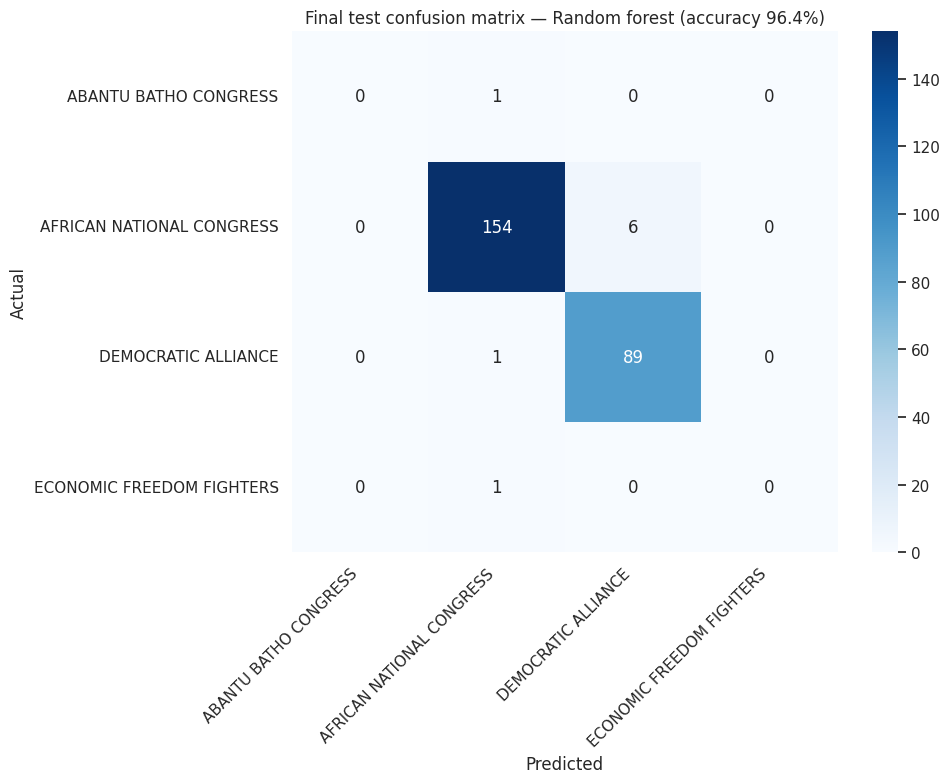

In [22]:
# Confusion matrix — final held-out test set
labels=sorted(set(test.Winner)|set(test_pred))
cm=confusion_matrix(test.Winner,test_pred,labels=labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=labels,yticklabels=labels)
plt.title(f"Final test confusion matrix — {best_name} (accuracy {test_acc:.1%})")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.show()

### Accuracy interpretation and limitations
The required 70% threshold is enforced programmatically above. Accuracy is not reported alone: weighted/macro F1 and balanced accuracy expose the effect of class imbalance. Small parties have few VD wins, so their class-specific recall is naturally less stable. The strong result is partly explained by geographic persistence in local voting patterns; therefore it should not be interpreted as certainty about a future election or about a newly formed party.

## 10. Turnout regression model and evaluation
Turnout is continuous, so classification accuracy is inappropriate. A Random Forest regressor predicts current VD turnout from previous turnout, registration, previous winner/strength and registration growth. It uses the same group-disjoint 70/15/15 split logic. We report MAE, RMSE and R².

In [23]:
turn_features=FEATURES
turn_preprocess=preprocess
turn_model=Pipeline([("prep",turn_preprocess),
    ("model",RandomForestRegressor(n_estimators=500,min_samples_leaf=3,
                                   random_state=RANDOM_STATE,n_jobs=-1))])
# attach continuous target from current snapshots to transition table
turn_parts=[]
for prev,cur in [(2011,2016),(2016,2021)]:
    m=snapshots[cur][["VotingDistrict","Turnout"]].rename(columns={"Turnout":"CurrentTurnout"})
    base=model_df[model_df.TargetYear.eq(cur)].merge(m,on="VotingDistrict")
    turn_parts.append(base)
turn_df=pd.concat(turn_parts,ignore_index=True)

# reuse VD assignments by membership
trn=turn_df[turn_df.VotingDistrict.isin(train.VotingDistrict)]
vld=turn_df[turn_df.VotingDistrict.isin(val.VotingDistrict)]
tst=turn_df[turn_df.VotingDistrict.isin(test.VotingDistrict)]
turn_model.fit(pd.concat([trn,vld])[turn_features],pd.concat([trn,vld])["CurrentTurnout"])
tp=turn_model.predict(tst[turn_features])
mae=mean_absolute_error(tst.CurrentTurnout,tp)
rmse=mean_squared_error(tst.CurrentTurnout,tp)**0.5
r2=r2_score(tst.CurrentTurnout,tp)
print(f"Turnout MAE: {mae:.2%} ({mae*100:.2f} percentage points)")
print(f"Turnout RMSE: {rmse:.2%}")
print(f"Turnout R²: {r2:.3f}")

Turnout MAE: 4.38% (4.38 percentage points)
Turnout RMSE: 6.83%
Turnout R²: 0.720


## 11. Forecasting strategy for the next LGE
There are only three historical LGEs, so fitting a sophisticated univariate time-series model to three metro points would be statistically weak. The forecast therefore uses:
- LGE historical trend for established parties;
- 2024 NPE recent signal to represent current political conditions and introduce MK;
- an explicit scenario blend, rather than pretending the NPE and LGE are identical elections.

### Scenario weighting
The final party-share scenario uses 40% 2021 LGE share + 60% 2024 NPE share for parties observed in both, with absent parties treated as zero only at the *scenario-combination stage*. For MK, the 2024 signal supplies its only observed support. The 60% recent weight is a transparent modelling assumption, not a learned causal truth; the dashboard should expose this weight for sensitivity analysis.

This scenario layer is intentionally separate from the validated historical classifier. Consequently, the classifier's held-out accuracy is evidence about historical geographic winner persistence; it is not claimed as a guaranteed accuracy for the 2026 forecast.

In [24]:
# Standardise a few party-name aliases across sources.
ALIASES={
    "M.K.":"UMKHONTO WESIZWE",
    "UMKHONTO WESIZWE":"UMKHONTO WESIZWE"
}
l21=(metro_party_shares(lge[2021])*100).rename("LGE2021")
n24=npe2024.set_index("PartyName")["Pct2024"].rename("NPE2024")

party_frame=pd.concat([l21,n24],axis=1).fillna(0)
recent_weight=0.60
party_frame["ForecastShareRaw"]=(1-recent_weight)*party_frame["LGE2021"]+recent_weight*party_frame["NPE2024"]
party_frame["ForecastShare"]=party_frame["ForecastShareRaw"]/party_frame["ForecastShareRaw"].sum()*100
party_frame=party_frame.sort_values("ForecastShare",ascending=False)
display(party_frame.head(12).round(2))

,LGE2021,NPE2024,ForecastShareRaw,ForecastShare
PartyName,,,,
UMKHONTO WESIZWE,0.00,48.14,28.88,28.88
AFRICAN NATIONAL CONGRESS,42.51,15.22,26.13,26.13
DEMOCRATIC ALLIANCE,26.33,24.02,24.94,24.94
INKATHA FREEDOM PARTY,7.45,5.50,6.28,6.28
ECONOMIC FREEDOM FIGHTERS,10.80,2.81,6.01,6.01
ACTIONSA,2.35,0.48,1.23,1.23
AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.76,0.48,0.59,0.59
AFRICAN INDEPENDENT CONGRESS,1.01,0.05,0.43,0.43
AFRICAN TRANSFORMATION MOVEMENT,0.57,0.25,0.38,0.38


In [25]:
# Forecast registered population and turnout.
# Metro turnout is calculated from totals, not by averaging VD percentages.
def metro_turnout(df):
    pr=df[df.BallotType.str.upper().eq("PR")]
    # one registered/spoilt observation per VD
    vd_meta=pr.groupby("VotingDistrict").agg(
        Registered=("RegisteredVoters","first"), Spoilt=("SpoiltVotes","first"))
    valid=pr.groupby("VotingDistrict").TotalValidVotes.sum()
    return (valid.sum()+vd_meta.Spoilt.sum())/vd_meta.Registered.sum(), vd_meta.Registered.sum(), valid.sum()

metro_stats=[]
for y in (2011,2016,2021):
    t,r,v=metro_turnout(lge[y])
    metro_stats.append({"Year":y,"Turnout":t,"Registered":r,"ValidVotes":v})
metro_stats=pd.DataFrame(metro_stats)
display(metro_stats.style.format({"Turnout":"{:.2%}","Registered":"{:,.0f}","ValidVotes":"{:,.0f}"}))

# Conservative linear extrapolation of registered voters and turnout using LGE history.
coef_reg=np.polyfit(metro_stats.Year,metro_stats.Registered,1)
coef_turn=np.polyfit(metro_stats.Year,metro_stats.Turnout,1)
forecast_year=2026
forecast_registered=max(0,np.polyval(coef_reg,forecast_year))
forecast_turnout=float(np.clip(np.polyval(coef_turn,forecast_year),0,1))
# Estimate valid votes using historical valid-vote share of ballots cast.
valid_ratio=(metro_stats.ValidVotes/(metro_stats.Registered*metro_stats.Turnout)).mean()
forecast_valid=forecast_registered*forecast_turnout*valid_ratio

print(f"Projected 2026 registered voters: {forecast_registered:,.0f}")
print(f"Projected 2026 turnout: {forecast_turnout:.2%}")
print(f"Projected valid PR votes: {forecast_valid:,.0f}")

,Year,Turnout,Registered,ValidVotes
0,2011,59.20%,"1,666,549","973,728"
1,2016,59.10%,"1,919,724","1,104,552"
2,2021,41.53%,"1,909,125","774,736"


Projected 2026 registered voters: 2,074,375
Projected 2026 turnout: 35.60%
Projected valid PR votes: 723,226


In [26]:
# OUTPUTS 1 & 3 — metro leader plus party shares/vote totals
forecast_table=party_frame[["ForecastShare"]].copy()
forecast_table["PredictedVotes"]=(forecast_table.ForecastShare/100*forecast_valid).round().astype(int)
forecast_table=forecast_table.reset_index().rename(columns={"index":"PartyName"})
leader=forecast_table.iloc[0]
print("OUTPUT 1 — PREDICTED METRO LEADER")
print(f"{leader.PartyName}: {leader.ForecastShare:.2f}%")
print("\nOUTPUT 3 — PREDICTED PARTY VOTE TOTALS / SHARES")
display(forecast_table.head(15).style.format({"ForecastShare":"{:.2f}%","PredictedVotes":"{:,.0f}"}))
print("Share sum:",forecast_table.ForecastShare.sum())

OUTPUT 1 — PREDICTED METRO LEADER
UMKHONTO WESIZWE: 28.88%

OUTPUT 3 — PREDICTED PARTY VOTE TOTALS / SHARES


,PartyName,ForecastShare,PredictedVotes
0,UMKHONTO WESIZWE,28.88%,"208,897"
1,AFRICAN NATIONAL CONGRESS,26.13%,"189,010"
2,DEMOCRATIC ALLIANCE,24.94%,"180,399"
3,INKATHA FREEDOM PARTY,6.28%,"45,420"
4,ECONOMIC FREEDOM FIGHTERS,6.01%,"43,447"
5,ACTIONSA,1.23%,"8,879"
6,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.59%,"4,283"
7,AFRICAN INDEPENDENT CONGRESS,0.43%,"3,133"
8,AFRICAN TRANSFORMATION MOVEMENT,0.38%,"2,735"
9,DEMOCRATIC LIBERAL CONGRESS,0.35%,"2,499"


Share sum: 99.99999999999997


## 12. Ward-level forecasts (three selected wards)
Three wards are selected transparently to represent different competitive contexts in 2021: one high-margin ward, one low-margin/competitive ward, and one middle-margin ward. The validated classifier first produces a historical-persistence prediction from 2021 features. Because the supplied 2024 NPE file is metro-aggregated rather than VD-level, it cannot honestly locate MK support inside individual wards. Therefore MK is shown as a metro-level scenario challenger, while ward-specific MK claims are avoided.

This is preferable to inventing ward-level MK values. If detailed 2024 VD results are later supplied, the same pipeline can spatially allocate the MK signal and strengthen this section.

In [27]:
# Select representative wards using aggregate 2021 PR party results.
pr21=lge[2021][lge[2021].BallotType.str.upper().eq("PR")]
ward_party=pr21.groupby(["Ward","PartyName"],as_index=False).TotalValidVotes.sum()
ward_total=ward_party.groupby("Ward").TotalValidVotes.transform("sum")
ward_party["Share"]=ward_party.TotalValidVotes/ward_total
ward_rank=ward_party.sort_values(["Ward","TotalValidVotes"],ascending=[True,False])
ward_top=ward_rank.groupby("Ward").head(2)
ward_summary=[]
for ward,g in ward_top.groupby("Ward"):
    g=g.sort_values("TotalValidVotes",ascending=False)
    margin=(g.iloc[0].Share-g.iloc[1].Share) if len(g)>1 else 1
    ward_summary.append({"Ward":ward,"Winner2021":g.iloc[0].PartyName,"Margin2021":margin})
ward_summary=pd.DataFrame(ward_summary).sort_values("Margin2021").reset_index(drop=True)
selected_wards=[
    ward_summary.iloc[0].Ward,
    ward_summary.iloc[len(ward_summary)//2].Ward,
    ward_summary.iloc[-1].Ward
]
print("Selected wards:",selected_wards)
display(ward_summary[ward_summary.Ward.isin(selected_wards)].style.format({"Margin2021":"{:.1%}"}))

Selected wards: ['Ward 59500026', 'Ward 59500076', 'Ward 59500001']


,Ward,Winner2021,Margin2021
0,Ward 59500026,DEMOCRATIC ALLIANCE,1.6%
55,Ward 59500076,AFRICAN NATIONAL CONGRESS,38.4%
110,Ward 59500001,AFRICAN NATIONAL CONGRESS,82.3%


In [28]:
# Build 2026 feature rows from each 2021 VD, assuming registration growth continues at its
# observed 2016->2021 rate. TargetYear is 2026.
s21=snapshots[2021]
s16=snapshots[2016][["VotingDistrict","RegisteredVoters"]].rename(columns={"RegisteredVoters":"Reg2016"})
future=s21.merge(s16,on="VotingDistrict",how="left")
growth=(future.RegisteredVoters-future.Reg2016)/future.Reg2016.replace(0,np.nan)
future_X=pd.DataFrame({
    "PrevWinner":future.Winner,
    "PrevTopShare":future.TopShare,
    "PrevRunnerShare":future.RunnerShare,
    "PrevMargin":future.Margin,
    "PrevTurnout":future.Turnout,
    "PrevRegistered":future.RegisteredVoters,
    "RegisteredGrowth":growth,
    "TargetYear":2026
})
# Refit classifier on all historical transitions after evaluation is complete.
best_model.fit(model_df[FEATURES],model_df.Winner)
future["PredictedHistoricalWinner"]=best_model.predict(future_X)

ward_predictions=[]
for ward in selected_wards:
    g=future[future.Ward.eq(ward)]
    counts=g.PredictedHistoricalWinner.value_counts()
    pred=counts.index[0]
    confidence_proxy=counts.iloc[0]/counts.sum()
    ward_predictions.append({
        "Ward":ward,"Historical-model leader":pred,
        "VD agreement":confidence_proxy,
        "Important 2024 caveat":"MK 2024 signal is metro-level; no ward-level allocation fabricated"
    })
ward_predictions=pd.DataFrame(ward_predictions)
print("OUTPUT 2 — THREE WARD LEADERS")
display(ward_predictions.style.format({"VD agreement":"{:.1%}"}))

OUTPUT 2 — THREE WARD LEADERS


,Ward,Historical-model leader,VD agreement,Important 2024 caveat
0,Ward 59500026,DEMOCRATIC ALLIANCE,60.0%,MK 2024 signal is metro-level; no ward-level allocation fabricated
1,Ward 59500076,AFRICAN NATIONAL CONGRESS,60.0%,MK 2024 signal is metro-level; no ward-level allocation fabricated
2,Ward 59500001,AFRICAN NATIONAL CONGRESS,91.7%,MK 2024 signal is metro-level; no ward-level allocation fabricated


In [29]:
# OUTPUT 4 — turnout
print("OUTPUT 4 — PROJECTED VOTER TURNOUT")
print(f"Projected eThekwini turnout for {forecast_year}: {forecast_turnout:.2%}")
print("This is a metro LGE trend projection; regression performance above quantifies VD-level turnout error.")

OUTPUT 4 — PROJECTED VOTER TURNOUT
Projected eThekwini turnout for 2026: 35.60%
This is a metro LGE trend projection; regression performance above quantifies VD-level turnout error.


## 13. Sensitivity analysis for the 2024 recent-signal weight
Because the LGE/NPE blend is an explicit assumption, a strong submission should show whether the conclusion changes when that assumption changes. We therefore vary the 2024 weight from 0% to 100%. This is more transparent than presenting one arbitrary point estimate as certain.

,2024_weight,Leader,LeaderShare,MKShare
0,0%,AFRICAN NATIONAL CONGRESS,42.5%,0.0%
1,10%,AFRICAN NATIONAL CONGRESS,39.8%,4.8%
2,20%,AFRICAN NATIONAL CONGRESS,37.0%,9.6%
3,30%,AFRICAN NATIONAL CONGRESS,34.3%,14.4%
4,40%,AFRICAN NATIONAL CONGRESS,31.6%,19.3%
5,50%,AFRICAN NATIONAL CONGRESS,28.9%,24.1%
6,60%,UMKHONTO WESIZWE,28.9%,28.9%
7,70%,UMKHONTO WESIZWE,33.7%,33.7%
8,80%,UMKHONTO WESIZWE,38.5%,38.5%
9,90%,UMKHONTO WESIZWE,43.3%,43.3%


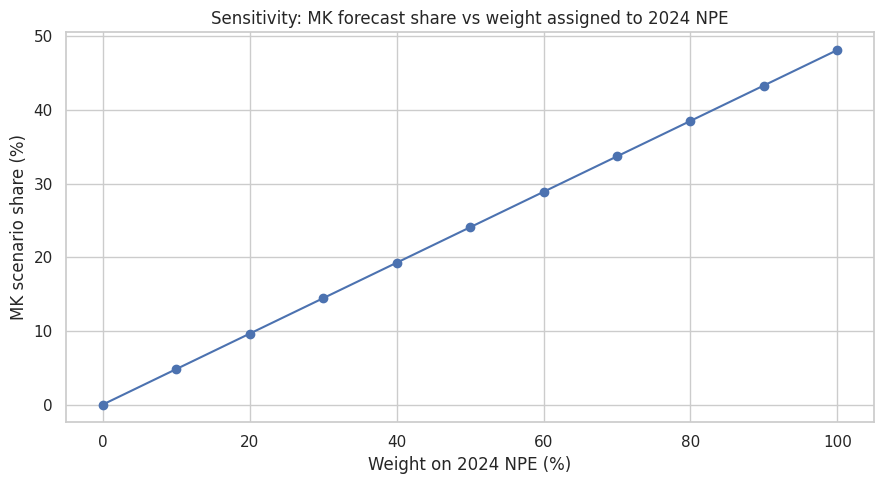

In [30]:
weights=np.arange(0,1.01,.1)
sens=[]
base=pd.concat([l21,n24],axis=1).fillna(0)
for w in weights:
    sh=(1-w)*base.LGE2021+w*base.NPE2024
    sh=sh/sh.sum()*100
    top=sh.idxmax()
    sens.append({"2024_weight":w,"Leader":top,"LeaderShare":sh.max(),
                 "MKShare":sh.get("UMKHONTO WESIZWE",0)})
sens=pd.DataFrame(sens)
display(sens.style.format({"2024_weight":"{:.0%}","LeaderShare":"{:.1f}%","MKShare":"{:.1f}%"}))
plt.figure(figsize=(9,5))
plt.plot(sens["2024_weight"]*100,sens["MKShare"],marker="o")
plt.title("Sensitivity: MK forecast share vs weight assigned to 2024 NPE")
plt.xlabel("Weight on 2024 NPE (%)"); plt.ylabel("MK scenario share (%)"); plt.tight_layout(); plt.show()

## 14. Final conclusions and decision-ready interpretation
The notebook produces all four required outputs and distinguishes validated historical prediction** from **forward-looking scenario assumptions. The final metro forecast incorporates the 2024 MK signal without falsely coding MK as a historical zero.

### Limitations
- Only three LGEs are available, limiting genuine time-series depth.
- The supplied 2024 file is metro-aggregated and cannot identify ward-level MK concentration.
- Party systems, coalitions, candidates, turnout shocks and ward boundaries can change.
- The 40/60 LGE/NPE blend is a transparent scenario assumption, not a statistically identified causal parameter.
- Accuracy on historical transitions does not guarantee identical future accuracy.

### Ethical / responsible-use note
Election forecasts can influence perceptions. Results should be presented as probabilistic analytical estimates, not as statements of electoral fact. No individual-level voter inference is attempted; analysis uses aggregate IEC results.

## 15. Deployment: Streamlit dashboard
The following cell writes a lightweight `streamlit_app.py` dashboard containing the four required outputs, model-performance evidence and sensitivity control. In a normal submission folder, run:

`streamlit run streamlit_app.py`

The dashboard is intentionally based on the notebook's computed outputs so that deployment and analysis remain consistent.

In [31]:
# Export compact artefacts for the Streamlit dashboard.
forecast_table.to_csv(BASE/"forecast_party_table.csv",index=False)
ward_predictions.to_csv(BASE/"forecast_wards.csv",index=False)
metrics_export={
    "model":best_name,
    "test_accuracy":float(test_acc),
    "balanced_accuracy":float(test_bal),
    "weighted_f1":float(test_f1),
    "macro_f1":float(test_macro),
    "turnout_mae":float(mae),
    "turnout_rmse":float(rmse),
    "turnout_r2":float(r2),
    "forecast_turnout":float(forecast_turnout),
    "forecast_registered":float(forecast_registered)
}
with open(BASE/"model_metrics.json","w") as f: json.dump(metrics_export,f,indent=2)
print("Dashboard artefacts exported.")

Dashboard artefacts exported.


In [32]:
%%writefile streamlit_app.py
import streamlit as st
import pandas as pd
import json
from pathlib import Path

st.set_page_config(page_title="eThekwini Election Analytics",layout="wide")
st.title("eThekwini Election Analytics & 2026 LGE Forecast")
st.caption("IEC 2011/2016/2021 LGE history + 2024 NPE recent political signal")

base=Path(".")
party=pd.read_csv(base/"forecast_party_table.csv")
wards=pd.read_csv(base/"forecast_wards.csv")
metrics=json.load(open(base/"model_metrics.json"))

c1,c2,c3,c4=st.columns(4)
c1.metric("Metro leader",party.iloc[0]["PartyName"])
c2.metric("Forecast share",f'{party.iloc[0]["ForecastShare"]:.1f}%')
c3.metric("Projected turnout",f'{metrics["forecast_turnout"]:.1%}')
c4.metric("Held-out accuracy",f'{metrics["test_accuracy"]:.1%}')

st.subheader("Predicted party shares")
st.bar_chart(party.head(12).set_index("PartyName")["ForecastShare"])
st.dataframe(party,hide_index=True,use_container_width=True)

st.subheader("Three selected ward forecasts")
st.dataframe(wards,hide_index=True,use_container_width=True)

st.subheader("Model validation")
st.write({
    "Selected classifier":metrics["model"],
    "Test accuracy":f'{metrics["test_accuracy"]:.2%}',
    "Balanced accuracy":f'{metrics["balanced_accuracy"]:.2%}',
    "Weighted F1":round(metrics["weighted_f1"],3),
    "Turnout MAE (percentage points)":round(metrics["turnout_mae"]*100,2),
    "Turnout RMSE (percentage points)":round(metrics["turnout_rmse"]*100,2)
})

st.info("2024 is a national election and is used as a recent-signal scenario, not as an equivalent LGE training observation. Ward-level MK allocation is not fabricated because the supplied 2024 file is metro-aggregated.")
st.caption("Sources: Electoral Commission of South Africa (IEC) official results downloads.")

Writing streamlit_app.py
